In [1]:
from image_dataset import TwoLabelDataset
import matplotlib.pyplot as plt
import slideflow as sf
import numpy as np

In [2]:
loaded_dataset = TwoLabelDataset.load(
    file_path='breast_cancer_test.npz',
    convert_grayscale_to_rgb=False 
)

print(f"Loaded dataset with {len(loaded_dataset.images)} images.")
print(f"First image shape: {loaded_dataset.images[0].shape}")
print(f"First labels1: {loaded_dataset.labels1[0]}")
print(f"First labels2: {loaded_dataset.labels2[0]}")

Loaded dataset with 6000 images.
First image shape: (224, 224, 3)
First labels1: 1
First labels2: 0


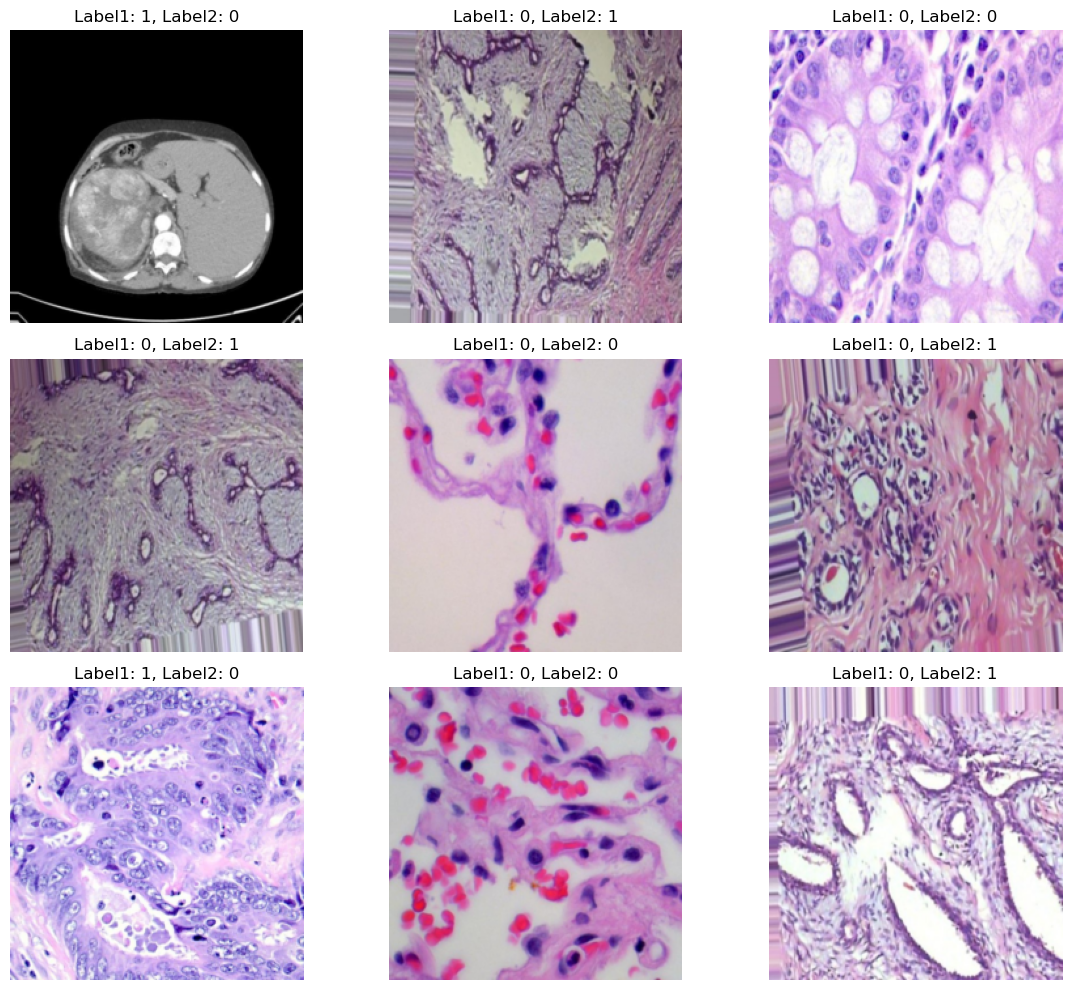

In [3]:
# Display a grid of images from the dataset
num_images_to_show = 9
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i in range(min(num_images_to_show, len(loaded_dataset.images))):
    img = loaded_dataset.images[i]
    
    # Handle both grayscale and RGB images
    if len(img.shape) == 2:  # Grayscale
        axes[i].imshow(img, cmap='gray')
    else:  # RGB
        axes[i].imshow(img)
    
    axes[i].set_title(f"Label1: {loaded_dataset.labels1[i]}, Label2: {loaded_dataset.labels2[i]}")
    axes[i].axis('off')

# Hide unused subplots
for i in range(num_images_to_show, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Make sure dataset is loaded
if 'loaded_dataset' not in locals():
    print("Loading dataset...")
    loaded_dataset = TwoLabelDataset.load(
        file_path='breast_cancer_test.npz',
        convert_grayscale_to_rgb=False
    )

print("Performing stain normalization on the dataset using SlideFlow...")
print(f"Original dataset: {len(loaded_dataset.images)} images")

# Apply stain normalization to all images
normalized_images = []

for i, img in enumerate(loaded_dataset.images):
    # Ensure image is uint8
    if img.dtype != np.uint8:
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
        else:
            img = img.astype(np.uint8)
    
    # Convert grayscale to RGB if needed
    if len(img.shape) == 2:
        img = np.stack([img] * 3, axis=-1)
    
    try:
        # Use SlideFlow's StainNormalizer class
        normalizer = sf.norm.StainNormalizer(method='macenko')
        normalized_img = normalizer.transform(img)
        normalized_images.append(normalized_img)
    except Exception as e:
        print(f"Error normalizing image {i}: {e}")
        # If normalization fails, use the original image
        normalized_images.append(img)
    
    if (i + 1) % 10 == 0:
        print(f"Normalized {i + 1} images...")

# Convert to numpy array
normalized_images = np.array(normalized_images)

print(f"\nStain normalization complete!")
print(f"Normalized images shape: {normalized_images.shape}")
print(f"Normalized image dtype: {normalized_images.dtype}")

# Define output filename
output_filename = 'breast_cancer_test_macenko_normalized.npz'

print(f"Saving normalized dataset to {output_filename}...")

# Save the normalized images with the same labels
np.savez_compressed(
    output_filename,
    images=normalized_images,
    labels1=loaded_dataset.labels1,
    labels2=loaded_dataset.labels2
)

print(f"✓ Successfully saved to {output_filename}")
print(f"\nDataset summary:")
print(f"  - Number of images: {len(normalized_images)}")
print(f"  - Image shape: {normalized_images[0].shape}")
print(f"  - Image dtype: {normalized_images.dtype}")

# Verify the saved file can be loaded
print(f"\nVerifying saved file...")
test_load = np.load(output_filename, allow_pickle=True)
print(f"✓ File verified - contains keys: {list(test_load.files)}")
print(f"✓ Loaded images shape: {test_load['images'].shape}")
print(f"✓ Loaded labels1 shape: {test_load['labels1'].shape}")
print(f"✓ Loaded labels2 shape: {test_load['labels2'].shape}")

Performing stain normalization on the dataset using SlideFlow...
Original dataset: 6000 images
Normalized 10 images...
Normalized 20 images...
Normalized 30 images...
Normalized 40 images...
Normalized 50 images...
Normalized 30 images...
Normalized 40 images...
Normalized 50 images...
Normalized 60 images...
Normalized 70 images...
Normalized 80 images...
Normalized 60 images...
Normalized 70 images...
Normalized 80 images...
Normalized 90 images...
Normalized 100 images...
Normalized 110 images...
Normalized 90 images...
Normalized 100 images...
Normalized 110 images...
Normalized 120 images...
Normalized 130 images...
Normalized 140 images...
Normalized 120 images...
Normalized 130 images...
Normalized 140 images...
Normalized 150 images...
Normalized 160 images...
Normalized 170 images...
Normalized 150 images...
Normalized 160 images...
Normalized 170 images...
Normalized 180 images...
Normalized 190 images...
Normalized 200 images...
Normalized 180 images...
Normalized 190 images

Loading both datasets for comparison...
✓ Original dataset: 6000 images
✓ Normalized dataset: 6000 images
✓ Original dataset: 6000 images
✓ Normalized dataset: 6000 images


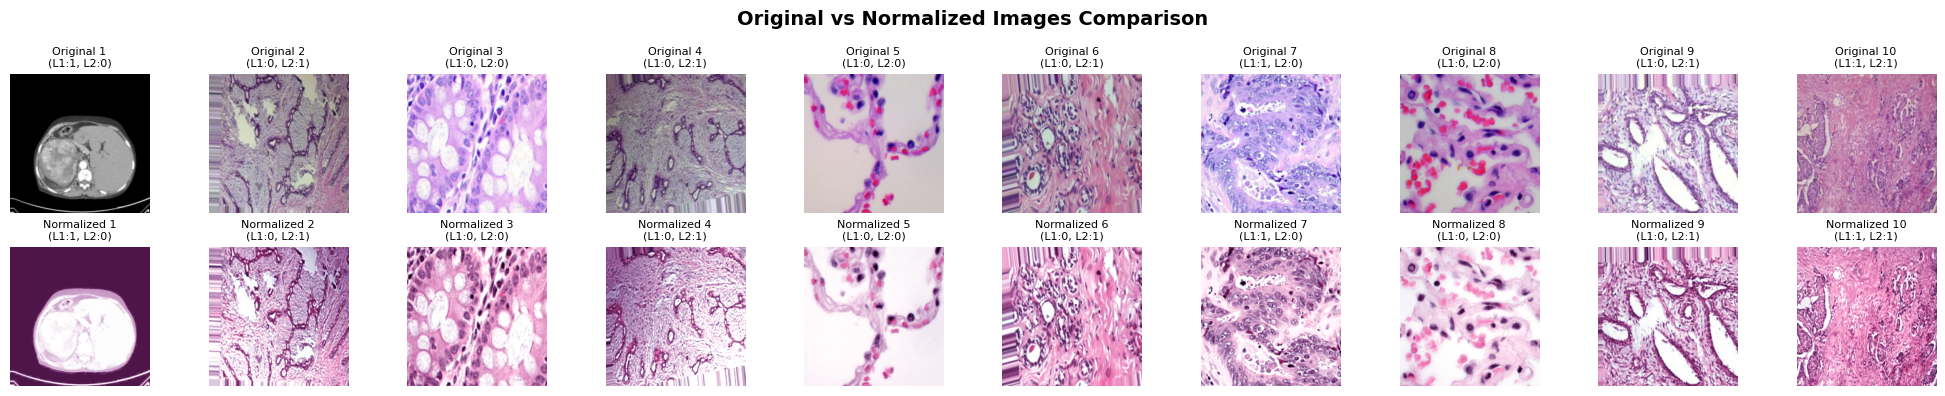


DATASET STATISTICS COMPARISON

Original Dataset:
  - Shape: (6000, 224, 224, 3)
  - Dtype: uint8
  - Min value: 0
  - Max value: 255
  - Mean value: 150.72
  - Mean value: 150.72
  - Std dev: 82.35

Normalized Dataset:
  - Shape: (6000, 224, 224, 3)
  - Dtype: uint8
  - Min value: 0
  - Max value: 255
  - Std dev: 82.35

Normalized Dataset:
  - Shape: (6000, 224, 224, 3)
  - Dtype: uint8
  - Min value: 0
  - Max value: 255
  - Mean value: 176.09
  - Mean value: 176.09
  - Std dev: 69.35

Label Distribution Comparison:

Original - labels1: (array([0, 1]), array([3000, 3000]))
Normalized - labels1: (array([0, 1]), array([3000, 3000]))

Original - labels2: (array([0, 1]), array([4529, 1471]))
Normalized - labels2: (array([0, 1]), array([4529, 1471]))

✓ Labels are preserved correctly after normalization!
  - Std dev: 69.35

Label Distribution Comparison:

Original - labels1: (array([0, 1]), array([3000, 3000]))
Normalized - labels1: (array([0, 1]), array([3000, 3000]))

Original - labels

In [5]:
print("Loading both datasets for comparison...")

# Load original dataset
original_dataset = TwoLabelDataset.load(
    file_path='breast_cancer_test.npz',
    convert_grayscale_to_rgb=False
)

# Load normalized dataset
normalized_dataset = TwoLabelDataset.load(
    file_path='breast_cancer_test_macenko_normalized.npz',
    convert_grayscale_to_rgb=False
)

print(f"✓ Original dataset: {len(original_dataset.images)} images")
print(f"✓ Normalized dataset: {len(normalized_dataset.images)} images")

# Display side-by-side comparison for multiple examples
num_examples = 10
fig, axes = plt.subplots(2, num_examples, figsize=(20, 4))

for i in range(num_examples):
    # Original image
    orig_img = original_dataset.images[i]
    if len(orig_img.shape) == 2:
        axes[0, i].imshow(orig_img, cmap='gray')
    else:
        axes[0, i].imshow(orig_img.astype(np.uint8) if orig_img.max() <= 1 else orig_img)
    axes[0, i].set_title(f"Original {i+1}\n(L1:{original_dataset.labels1[i]}, L2:{original_dataset.labels2[i]})", fontsize=8)
    axes[0, i].axis('off')
    
    # Normalized image
    norm_img = normalized_dataset.images[i]
    if len(norm_img.shape) == 2:
        axes[1, i].imshow(norm_img, cmap='gray')
    else:
        axes[1, i].imshow(norm_img)
    axes[1, i].set_title(f"Normalized {i+1}\n(L1:{normalized_dataset.labels1[i]}, L2:{normalized_dataset.labels2[i]})", fontsize=8)
    axes[1, i].axis('off')

fig.suptitle('Original vs Normalized Images Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistics comparison
print("\n" + "="*60)
print("DATASET STATISTICS COMPARISON")
print("="*60)

print("\nOriginal Dataset:")
print(f"  - Shape: {original_dataset.images.shape}")
print(f"  - Dtype: {original_dataset.images.dtype}")
print(f"  - Min value: {original_dataset.images.min()}")
print(f"  - Max value: {original_dataset.images.max()}")
print(f"  - Mean value: {original_dataset.images.mean():.2f}")
print(f"  - Std dev: {original_dataset.images.std():.2f}")

print("\nNormalized Dataset:")
print(f"  - Shape: {normalized_dataset.images.shape}")
print(f"  - Dtype: {normalized_dataset.images.dtype}")
print(f"  - Min value: {normalized_dataset.images.min()}")
print(f"  - Max value: {normalized_dataset.images.max()}")
print(f"  - Mean value: {normalized_dataset.images.mean():.2f}")
print(f"  - Std dev: {normalized_dataset.images.std():.2f}")

print("\nLabel Distribution Comparison:")
print(f"\nOriginal - labels1: {np.unique(original_dataset.labels1, return_counts=True)}")
print(f"Normalized - labels1: {np.unique(normalized_dataset.labels1, return_counts=True)}")
print(f"\nOriginal - labels2: {np.unique(original_dataset.labels2, return_counts=True)}")
print(f"Normalized - labels2: {np.unique(normalized_dataset.labels2, return_counts=True)}")
print("\n✓ Labels are preserved correctly after normalization!")

In [7]:
# Apply Reinhard Stain Normalization to ALL images and save
print("="*70)
print("REINHARD STAIN NORMALIZATION - FULL DATASET")
print("="*70)

# Make sure dataset is loaded
if 'loaded_dataset' not in locals():
    print("Loading dataset...")
    loaded_dataset = TwoLabelDataset.load(
        file_path='breast_cancer_test.npz',
        convert_grayscale_to_rgb=False
    )

print(f"\nProcessing dataset with Reinhard normalization...")
print(f"Original dataset: {len(loaded_dataset.images)} images")

# Apply Reinhard stain normalization to all images
reinhard_normalized_images = []

for i, img in enumerate(loaded_dataset.images):
    try:
        # Ensure image is uint8
        if img.dtype != np.uint8:
            if img.max() <= 1.0:
                img_uint8 = (img * 255).astype(np.uint8)
            else:
                img_uint8 = img.astype(np.uint8)
        else:
            img_uint8 = img.copy()
        
        # Convert grayscale to RGB if needed
        if len(img_uint8.shape) == 2:
            img_rgb = np.stack([img_uint8] * 3, axis=-1)
        else:
            img_rgb = img_uint8
        
        # Apply Reinhard normalization using SlideFlow
        normalizer = sf.norm.StainNormalizer(method='reinhard')
        normalized_img = normalizer.transform(img_rgb)
        reinhard_normalized_images.append(normalized_img)
        
    except Exception as e:
        print(f"Error normalizing image {i}: {str(e)[:60]}")
        # If normalization fails, use the original image
        if len(img_uint8.shape) == 2:
            reinhard_normalized_images.append(np.stack([img_uint8] * 3, axis=-1))
        else:
            reinhard_normalized_images.append(img_uint8)
    
    # Progress update
    if (i + 1) % 10 == 0:
        print(f"  ✓ Processed {i + 1} images...")

# Convert to numpy array
reinhard_normalized_images = np.array(reinhard_normalized_images)

print(f"\n✓ Reinhard normalization complete!")
print(f"Normalized images shape: {reinhard_normalized_images.shape}")
print(f"Normalized image dtype: {reinhard_normalized_images.dtype}")

# Save the normalized dataset
output_filename = 'breast_cancer_test_reinhard_normalized.npz'

print(f"\n{'='*70}")
print(f"Saving normalized dataset to {output_filename}...")
print(f"{'='*70}")

# Save the normalized images with the same labels
np.savez_compressed(
    output_filename,
    images=reinhard_normalized_images,
    labels1=loaded_dataset.labels1,
    labels2=loaded_dataset.labels2
)

print(f"✓ Successfully saved to {output_filename}")
print(f"\nDataset summary:")
print(f"  - Number of images: {len(reinhard_normalized_images)}")
print(f"  - Image shape: {reinhard_normalized_images[0].shape}")
print(f"  - Image dtype: {reinhard_normalized_images.dtype}")

# Verify the saved file
print(f"\nVerifying saved file...")
test_load = np.load(output_filename, allow_pickle=True)
print(f"✓ File verified - contains keys: {list(test_load.files)}")
print(f"✓ Loaded images shape: {test_load['images'].shape}")
print(f"✓ Loaded labels1 shape: {test_load['labels1'].shape}")
print(f"✓ Loaded labels2 shape: {test_load['labels2'].shape}")

print(f"\n{'='*70}")
print("File saved successfully!")
print(f"{'='*70}")

REINHARD STAIN NORMALIZATION - FULL DATASET

Processing dataset with Reinhard normalization...
Original dataset: 6000 images
  ✓ Processed 10 images...
  ✓ Processed 20 images...
  ✓ Processed 30 images...
  ✓ Processed 20 images...
  ✓ Processed 30 images...
  ✓ Processed 40 images...
  ✓ Processed 50 images...
  ✓ Processed 40 images...
  ✓ Processed 50 images...
  ✓ Processed 60 images...
  ✓ Processed 70 images...
  ✓ Processed 60 images...
  ✓ Processed 70 images...
  ✓ Processed 80 images...
  ✓ Processed 90 images...
  ✓ Processed 80 images...
  ✓ Processed 90 images...
  ✓ Processed 100 images...
  ✓ Processed 110 images...
  ✓ Processed 100 images...
  ✓ Processed 110 images...
  ✓ Processed 120 images...
  ✓ Processed 130 images...
  ✓ Processed 120 images...
  ✓ Processed 130 images...
  ✓ Processed 140 images...
  ✓ Processed 150 images...
  ✓ Processed 140 images...
  ✓ Processed 150 images...
  ✓ Processed 160 images...
  ✓ Processed 170 images...
  ✓ Processed 160 images

ORIGINAL vs REINHARD NORMALIZED - COMPARISON

Loading datasets for comparison...
✓ Original dataset: 6000 images
✓ Reinhard normalized dataset: 6000 images


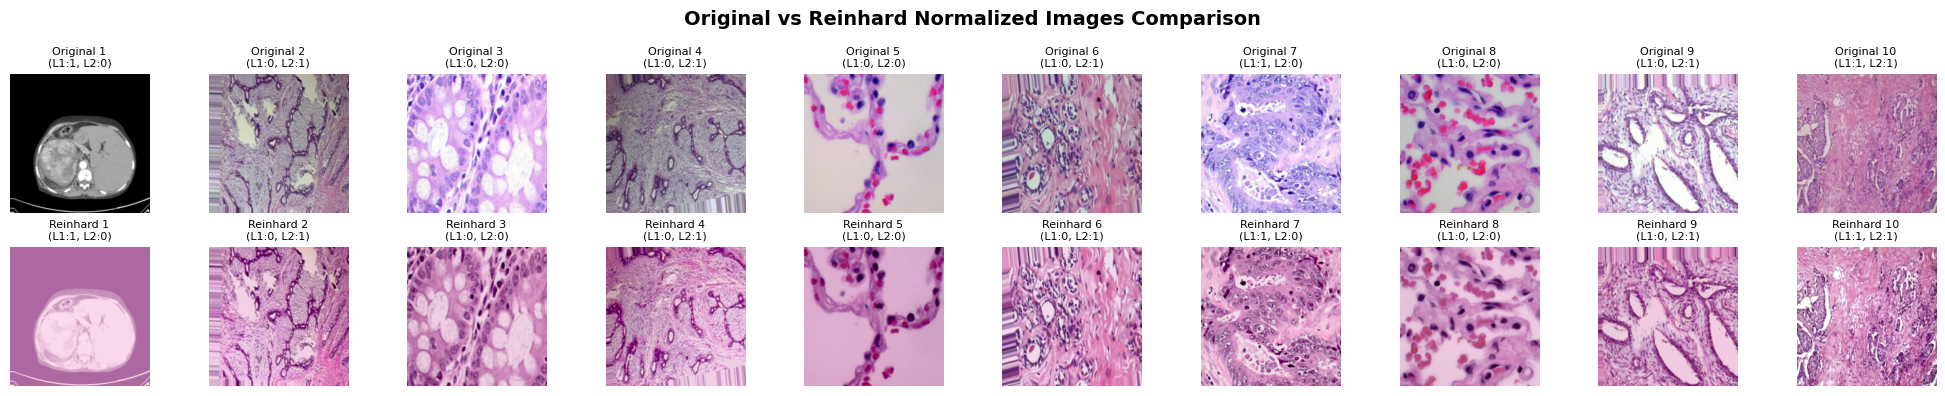


DATASET STATISTICS COMPARISON

Original Dataset:
  - Shape: (6000, 224, 224, 3)
  - Dtype: uint8
  - Min value: 0.00
  - Max value: 255.00
  - Mean value: 150.72
  - Std dev: 82.35

Reinhard Normalized Dataset:
  - Shape: (6000, 224, 224, 3)
  - Dtype: uint8
  - Min value: 0.00
  - Max value: 255.00
  - Mean value: 173.84
  - Std dev: 45.96

Label Distribution Comparison:

Original - labels1: (array([0, 1]), array([3000, 3000]))
Reinhard - labels1: (array([0, 1]), array([3000, 3000]))

Original - labels2: (array([0, 1]), array([4529, 1471]))
Reinhard - labels2: (array([0, 1]), array([4529, 1471]))

✓ Labels are preserved correctly after Reinhard normalization!

STATISTICAL DIFFERENCES

Mean:
  Original:  150.72
  Reinhard:  173.84
  Difference: +23.12 (+15.3%)

Standard Deviation:
  Original:  82.35
  Reinhard:  45.96
  Difference: -36.40 (-44.2%)

✓ Comparison complete!


In [8]:
# Load and Compare Original vs Reinhard Normalized Dataset
print("="*70)
print("ORIGINAL vs REINHARD NORMALIZED - COMPARISON")
print("="*70)

print("\nLoading datasets for comparison...")

# Load original dataset
original_dataset = TwoLabelDataset.load(
    file_path='breast_cancer_test.npz',
    convert_grayscale_to_rgb=False
)

# Load Reinhard normalized dataset
reinhard_dataset = TwoLabelDataset.load(
    file_path='breast_cancer_test_reinhard_normalized.npz',
    convert_grayscale_to_rgb=False
)

print(f"✓ Original dataset: {len(original_dataset.images)} images")
print(f"✓ Reinhard normalized dataset: {len(reinhard_dataset.images)} images")

# Display side-by-side comparison for multiple examples
num_examples = 10
fig, axes = plt.subplots(2, num_examples, figsize=(20, 4))

for i in range(num_examples):
    # Original image
    orig_img = original_dataset.images[i]
    if len(orig_img.shape) == 2:
        axes[0, i].imshow(orig_img, cmap='gray')
    else:
        axes[0, i].imshow(orig_img.astype(np.uint8) if orig_img.max() <= 1 else orig_img)
    axes[0, i].set_title(f"Original {i+1}\n(L1:{original_dataset.labels1[i]}, L2:{original_dataset.labels2[i]})", fontsize=8)
    axes[0, i].axis('off')
    
    # Reinhard normalized image
    reinhard_img = reinhard_dataset.images[i]
    if len(reinhard_img.shape) == 2:
        axes[1, i].imshow(reinhard_img, cmap='gray')
    else:
        axes[1, i].imshow(reinhard_img)
    axes[1, i].set_title(f"Reinhard {i+1}\n(L1:{reinhard_dataset.labels1[i]}, L2:{reinhard_dataset.labels2[i]})", fontsize=8)
    axes[1, i].axis('off')

fig.suptitle('Original vs Reinhard Normalized Images Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistics comparison
print("\n" + "="*70)
print("DATASET STATISTICS COMPARISON")
print("="*70)

print("\nOriginal Dataset:")
print(f"  - Shape: {original_dataset.images.shape}")
print(f"  - Dtype: {original_dataset.images.dtype}")
print(f"  - Min value: {original_dataset.images.min():.2f}")
print(f"  - Max value: {original_dataset.images.max():.2f}")
print(f"  - Mean value: {original_dataset.images.mean():.2f}")
print(f"  - Std dev: {original_dataset.images.std():.2f}")

print("\nReinhard Normalized Dataset:")
print(f"  - Shape: {reinhard_dataset.images.shape}")
print(f"  - Dtype: {reinhard_dataset.images.dtype}")
print(f"  - Min value: {reinhard_dataset.images.min():.2f}")
print(f"  - Max value: {reinhard_dataset.images.max():.2f}")
print(f"  - Mean value: {reinhard_dataset.images.mean():.2f}")
print(f"  - Std dev: {reinhard_dataset.images.std():.2f}")

print("\nLabel Distribution Comparison:")
print(f"\nOriginal - labels1: {np.unique(original_dataset.labels1, return_counts=True)}")
print(f"Reinhard - labels1: {np.unique(reinhard_dataset.labels1, return_counts=True)}")
print(f"\nOriginal - labels2: {np.unique(original_dataset.labels2, return_counts=True)}")
print(f"Reinhard - labels2: {np.unique(reinhard_dataset.labels2, return_counts=True)}")
print("\n✓ Labels are preserved correctly after Reinhard normalization!")

# Calculate statistics differences
print("\n" + "="*70)
print("STATISTICAL DIFFERENCES")
print("="*70)

orig_mean = original_dataset.images.mean()
reinhard_mean = reinhard_dataset.images.mean()
mean_diff = reinhard_mean - orig_mean
mean_diff_pct = (mean_diff / orig_mean) * 100 if orig_mean != 0 else 0

orig_std = original_dataset.images.std()
reinhard_std = reinhard_dataset.images.std()
std_diff = reinhard_std - orig_std
std_diff_pct = (std_diff / orig_std) * 100 if orig_std != 0 else 0

print(f"\nMean:")
print(f"  Original:  {orig_mean:.2f}")
print(f"  Reinhard:  {reinhard_mean:.2f}")
print(f"  Difference: {mean_diff:+.2f} ({mean_diff_pct:+.1f}%)")

print(f"\nStandard Deviation:")
print(f"  Original:  {orig_std:.2f}")
print(f"  Reinhard:  {reinhard_std:.2f}")
print(f"  Difference: {std_diff:+.2f} ({std_diff_pct:+.1f}%)")

print("\n✓ Comparison complete!")


Testing all available SlideFlow stain normalization algorithms...

Processing 8 images with all available normalization methods...

Applying MACENKO normalization...
  ✓ MACENKO normalization complete!

Applying REINHARD normalization...
  ✓ REINHARD normalization complete!

Successfully applied 2 normalization algorithms



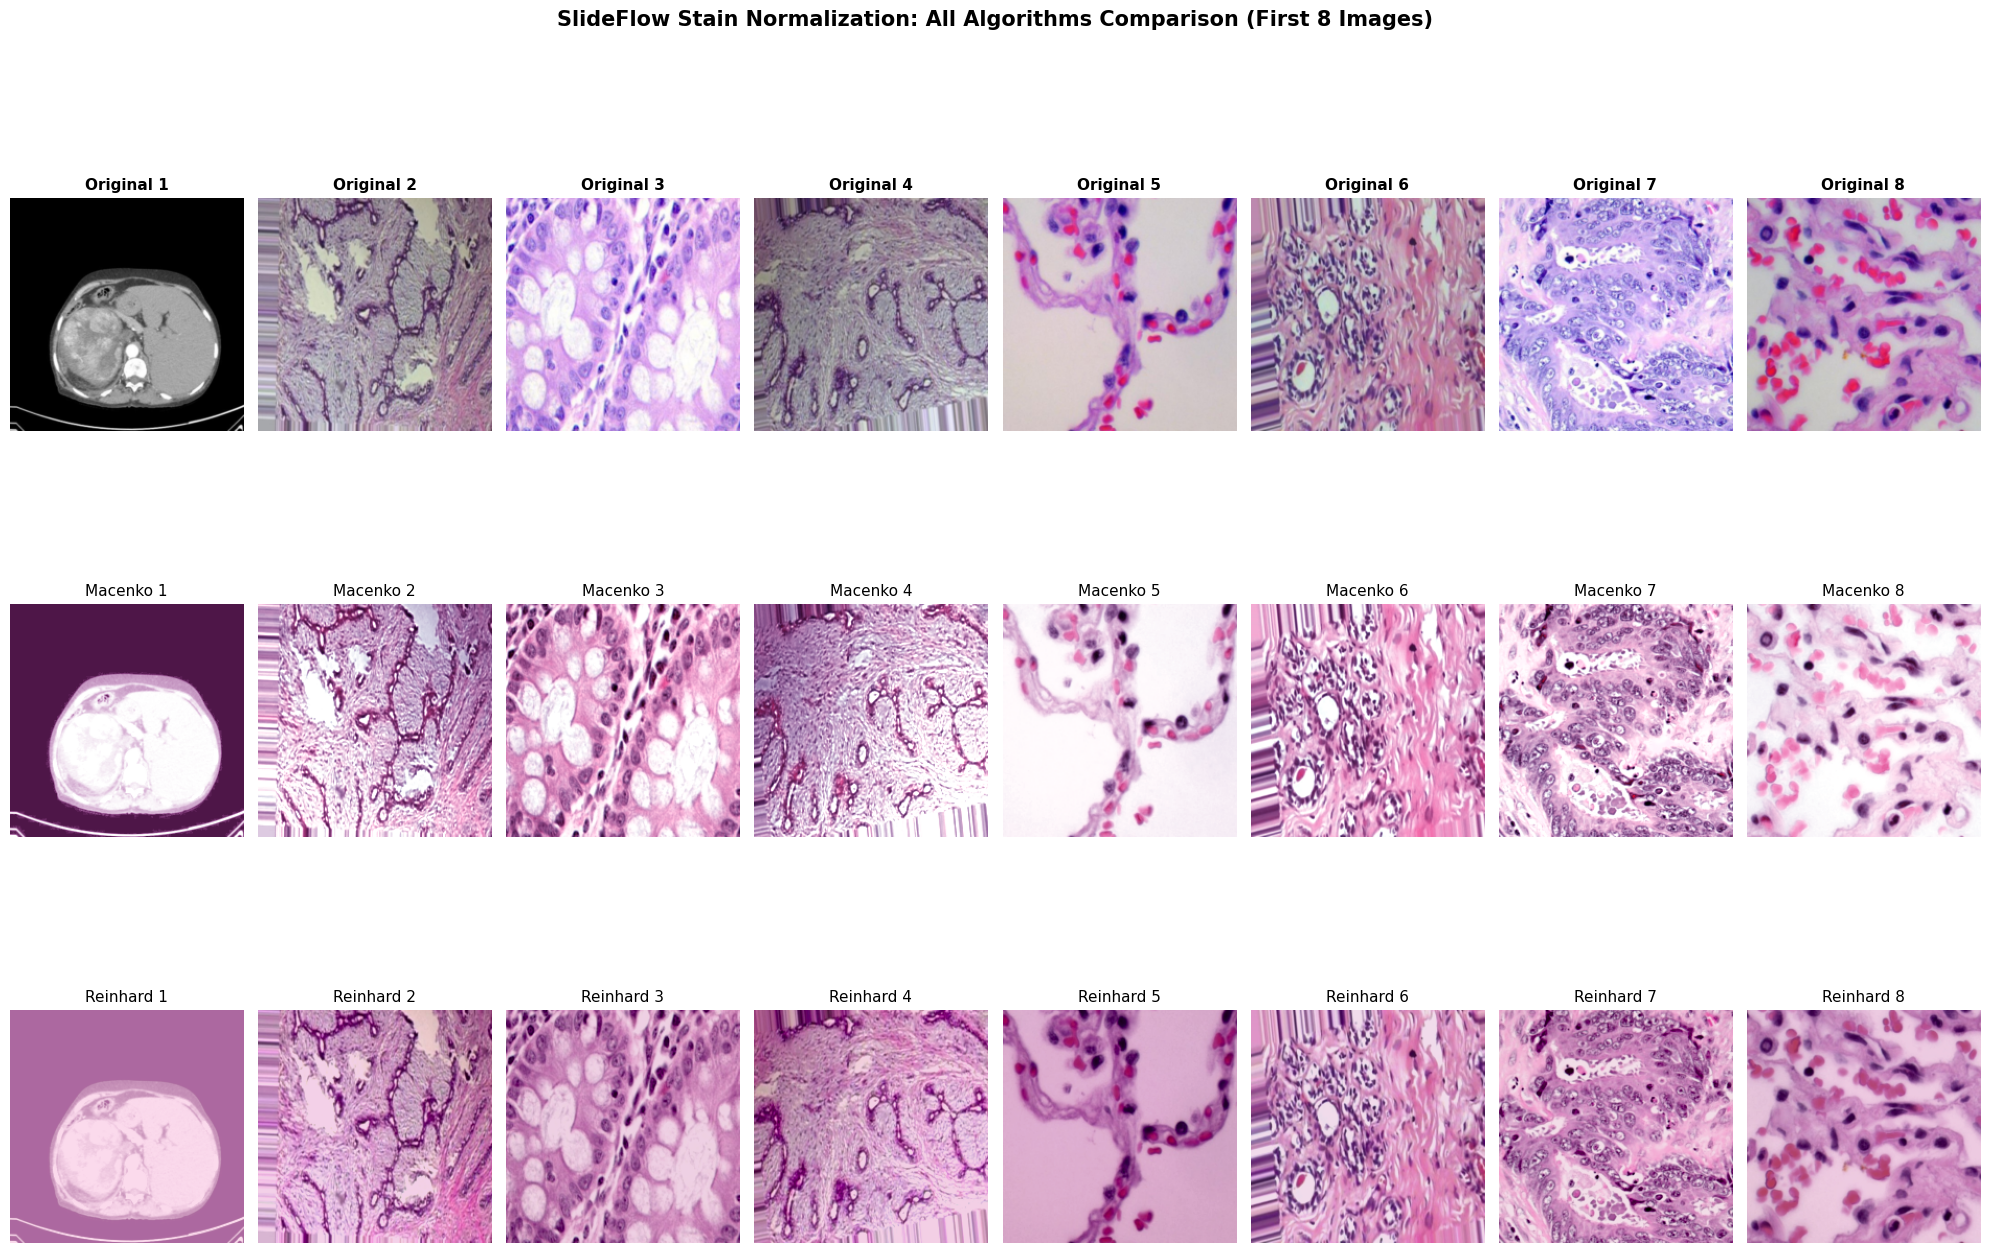

DETAILED STATISTICS FOR ALL NORMALIZATION METHODS

ORIGINAL IMAGES (First 8):
  - Shape: (8, 224, 224, 3)
  - Dtype: uint8
  - Min: 0.00, Max: 255.00
  - Mean: 159.23, Std: 63.87

MACENKO NORMALIZED IMAGES:
  - Shape: (8, 224, 224, 3)
  - Dtype: uint8
  - Min: 0.00, Max: 255.00
  - Mean: 192.17, Std: 62.64

REINHARD NORMALIZED IMAGES:
  - Shape: (8, 224, 224, 3)
  - Dtype: uint8
  - Min: 0.00, Max: 251.00
  - Mean: 173.97, Std: 46.36

PER-IMAGE ANALYSIS

──────────────────────────────────────────────────────────────────────
IMAGE 1:
──────────────────────────────────────────────────────────────────────

  Original      - Mean: 55.76, Std: 75.66, Min: 0.00, Max: 255.00
  Macenko    - Mean: 128.26, Std: 90.83, Min: 22.00, Max: 255.00
  Reinhard   - Mean: 173.99, Std: 45.85, Min: 104.00, Max: 251.00

──────────────────────────────────────────────────────────────────────
IMAGE 2:
──────────────────────────────────────────────────────────────────────

  Original      - Mean: 148.94, Std: 33

In [9]:
# All SlideFlow Stain Normalization Algorithms on first 8 images
print("Testing all available SlideFlow stain normalization algorithms...\n")

# Make sure dataset is loaded
if 'loaded_dataset' not in locals():
    print("Loading dataset...")
    loaded_dataset = TwoLabelDataset.load(
        file_path='breast_cancer_test.npz',
        convert_grayscale_to_rgb=False
    )

# Extract first 8 images
num_images = min(8, len(loaded_dataset.images))
original_images = loaded_dataset.images[:num_images].copy()

print(f"Processing {num_images} images with all available normalization methods...\n")

# Available stain normalization methods in SlideFlow
methods = ['macenko', 'reinhard']

# Store results
results = {'original': original_images}

# Apply each normalization method
for method in methods:
    print(f"Applying {method.upper()} normalization...")
    normalized_images_method = []
    
    for i, img in enumerate(original_images):
        try:
            # Ensure image is uint8
            if img.dtype != np.uint8:
                if img.max() <= 1.0:
                    img_uint8 = (img * 255).astype(np.uint8)
                else:
                    img_uint8 = img.astype(np.uint8)
            else:
                img_uint8 = img.copy()
            
            # Convert grayscale to RGB if needed
            if len(img_uint8.shape) == 2:
                img_rgb = np.stack([img_uint8] * 3, axis=-1)
            else:
                img_rgb = img_uint8
            
            # Apply normalization using SlideFlow
            normalizer = sf.norm.StainNormalizer(method=method)
            normalized_img = normalizer.transform(img_rgb)
            normalized_images_method.append(normalized_img)
            
        except Exception as e:
            print(f"  ⚠ Error normalizing image {i+1} with {method}: {str(e)[:60]}")
            # Use original image if normalization fails
            if len(img_uint8.shape) == 2:
                normalized_images_method.append(np.stack([img_uint8] * 3, axis=-1))
            else:
                normalized_images_method.append(img_uint8)
    
    results[method] = np.array(normalized_images_method)
    print(f"  ✓ {method.upper()} normalization complete!\n")

print("="*70)
print(f"Successfully applied {len(methods)} normalization algorithms")
print("="*70 + "\n")

# Display comparison grid
fig, axes = plt.subplots(len(methods) + 1, num_images, figsize=(20, 14))

# Original row
for i in range(num_images):
    img = original_images[i]
    if len(img.shape) == 2:
        axes[0, i].imshow(img, cmap='gray')
    else:
        if img.max() <= 1:
            axes[0, i].imshow((img * 255).astype(np.uint8))
        else:
            axes[0, i].imshow(img.astype(np.uint8))
    axes[0, i].set_title(f"Original {i+1}", fontsize=11, fontweight='bold', color='black')
    axes[0, i].axis('off')

# Normalized rows for each method
for method_idx, method in enumerate(methods):
    for i in range(num_images):
        img = results[method][i]
        axes[method_idx + 1, i].imshow(img)
        axes[method_idx + 1, i].set_title(f"{method.capitalize()} {i+1}", fontsize=11)
        axes[method_idx + 1, i].axis('off')

fig.suptitle('SlideFlow Stain Normalization: All Algorithms Comparison (First 8 Images)', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print detailed statistics for each method
print("="*70)
print("DETAILED STATISTICS FOR ALL NORMALIZATION METHODS")
print("="*70)

print("\nORIGINAL IMAGES (First 8):")
print(f"  - Shape: {original_images.shape}")
print(f"  - Dtype: {original_images.dtype}")
print(f"  - Min: {original_images.min():.2f}, Max: {original_images.max():.2f}")
print(f"  - Mean: {original_images.mean():.2f}, Std: {original_images.std():.2f}")

for method in methods:
    normalized_array = results[method]
    print(f"\n{method.upper()} NORMALIZED IMAGES:")
    print(f"  - Shape: {normalized_array.shape}")
    print(f"  - Dtype: {normalized_array.dtype}")
    print(f"  - Min: {normalized_array.min():.2f}, Max: {normalized_array.max():.2f}")
    print(f"  - Mean: {normalized_array.mean():.2f}, Std: {normalized_array.std():.2f}")

# Per-image comparison
print("\n" + "="*70)
print("PER-IMAGE ANALYSIS")
print("="*70)

for i in range(num_images):
    print(f"\n{'─'*70}")
    print(f"IMAGE {i+1}:")
    print(f"{'─'*70}")
    
    orig = original_images[i]
    print(f"\n  Original      - Mean: {orig.mean():.2f}, Std: {orig.std():.2f}, Min: {orig.min():.2f}, Max: {orig.max():.2f}")
    
    for method in methods:
        norm = results[method][i]
        print(f"  {method.capitalize():10} - Mean: {norm.mean():.2f}, Std: {norm.std():.2f}, Min: {norm.min():.2f}, Max: {norm.max():.2f}")

# Summary table
print("\n" + "="*70)
print("ALGORITHM SUMMARY")
print("="*70)
print("\nMethods applied:")
print("  1. Macenko   - Color deconvolution based stain matrix estimation")
print("  2. Reinhard  - Statistical color matching in LAB color space")
print("  3. Vahadane  - Unsupervised stain matrix estimation via dictionary learning")

print("\nKey Observations:")
for method in methods:
    arr = results[method]
    orig_std = original_images.std()
    method_std = arr.std()
    change_pct = ((method_std - orig_std) / orig_std) * 100
    print(f"  - {method.capitalize()}: Std change: {change_pct:+.1f}%")

print("\n✓ Complete analysis finished!")
